#  County-Level Election Prediction


 **XGBoost with Optuna Tuning**  Gradient boosting + automated hyperparameter search

 **Neural Network (MLP)**  Deep learning on tabular features

**Stacked Ensemble**  Meta-learner combines LR + RF + XGB predictions



In [ ]:
# Install required packages
!pip install xgboost optuna shap --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# XGBoost & Optuna
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap



## 1. Load & Prepare Data

In [ ]:
df = pd.read_csv("/content/model_ready_dataset.csv")
print(f'Dataset shape: {df.shape}')
print(f'Target distribution:\n{df["party_winner"].value_counts()}')
df.head(3)

Dataset shape: (3115, 186)
Target distribution:
party_winner
0    2576
1     539
Name: count, dtype: int64


,county_fips,B01001_001E,B01001_002E,B01001_003E,B01001_004E,B01001_005E,B01001_006E,B01001_007E,B01001_008E,B01001_009E,...,asian_population,total_housing_units,higher_education_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,log_population,pop_density_proxy
0,1001,55639,27052,1727,2156,1674,1208,553,395,225,...,649,23697,0.192689,0.150865,0.028280,0.757562,0.195295,0.011664,10.926658,2.347934
1,1003,218289,105889,6082,5197,8289,4305,2406,1177,792,...,2033,116747,0.227387,0.090426,0.039053,0.854390,0.087741,0.009313,12.293580,1.869761
2,1005,25026,13156,660,741,721,467,261,365,103,...,122,12057,0.082594,0.252218,0.069367,0.462998,0.476664,0.004875,10.127711,2.075641


In [ ]:
#  Feature Sets

HISTORICAL_FEATURES = [
    'swing_2016_2020', 'swing_2012_2020', 'swing_2000_2020',
    'vote_volatility', 'dem_wins_count', 'flipped'
]

DEMOGRAPHIC_FEATURES = [
    'higher_education_rate', 'poverty_rate', 'unemployment_rate',
    'white_pct', 'black_pct', 'asian_pct',
    'log_population', 'pop_density_proxy',
    'median_income'
]

#
ALL_FEATURES = HISTORICAL_FEATURES + DEMOGRAPHIC_FEATURES

TARGET = 'party_winner'

# Drop rows with NaN in features or target
data = df[ALL_FEATURES + [TARGET]].dropna()

X = data[ALL_FEATURES]
y = data[TARGET]   # 0 = Republican, 1 = Democrat (or whatever encoding exists)

print(f'Clean samples: {len(data)}')
print(f'Class balance: {y.value_counts().to_dict()}')

Clean samples: 3113
Class balance: {0: 2576, 1: 537}


In [ ]:
#  Feature Engineering



X = X.copy()

# 1. Interaction: education × income (captures college-educated affluent counties)
X['edu_income_interaction'] = X['higher_education_rate'] * X['median_income']

# 2. Racial diversity index (Herfindahl-Hirschman style)
X['diversity_index'] = 1 - (X['white_pct']**2 + X['black_pct']**2 + X['asian_pct']**2)

# 3. Economic stress composite
X['economic_stress'] = X['poverty_rate'] + X['unemployment_rate']

# 4. Swing momentum: recent minus long-term
X['swing_momentum'] = X['swing_2016_2020'] - X['swing_2000_2020']

ENGINEERED = ['edu_income_interaction', 'diversity_index', 'economic_stress', 'swing_momentum']
print(f'Total features after engineering: {X.shape[1]}')
X.head(3)

Total features after engineering: 19


,swing_2016_2020,swing_2012_2020,swing_2000_2020,vote_volatility,dem_wins_count,flipped,higher_education_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,log_population,pop_density_proxy,median_income,edu_income_interaction,diversity_index,economic_stress,swing_momentum
0,0.028198,0.006417,-0.017399,0.017765,0,0,0.192689,0.150865,0.028280,0.757562,0.195295,0.011664,10.926658,2.347934,57982.0,11172.469347,0.387824,0.179146,0.045596
1,0.025239,0.009127,-0.027781,0.018555,0,0,0.227387,0.090426,0.039053,0.854390,0.087741,0.009313,12.293580,1.869761,61756.0,14042.488701,0.262232,0.129479,0.053021
2,-0.010376,-0.054400,-0.043082,0.031798,2,0,0.082594,0.252218,0.069367,0.462998,0.476664,0.004875,10.127711,2.075641,34990.0,2889.967634,0.558400,0.321585,0.032705


In [ ]:
#  Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled versions (for LR and MLP)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (2490, 19) | Test: (623, 19)


---
## Approach 1 — XGBoost with Optuna Hyperparameter Tuning

> **Why this is different from the original:** The original used default/grid-searched Random Forest and Decision Tree. XGBoost uses gradient boosting (sequential correction of errors) which is generally more powerful, and Optuna performs **Bayesian optimization** — far more efficient than grid search for finding optimal hyperparameters.

In [ ]:
#  Optuna Objective Function
def xgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 500),
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'gamma':              trial.suggest_float('gamma', 0, 5),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        'use_label_encoder':  False,
        'eval_metric':        'logloss',
        'random_state':       42,
        'n_jobs':             -1
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()

# Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f' Best ROC-AUC (CV): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

 Best ROC-AUC (CV): 1.0000
Best params: {'n_estimators': 484, 'max_depth': 10, 'learning_rate': 0.021673074900008114, 'subsample': 0.8798974242399816, 'colsample_bytree': 0.9746682245860713, 'min_child_weight': 1, 'gamma': 0.8956757570871049, 'reg_alpha': 0.00022377070409151923, 'reg_lambda': 1.3045816975381745}


In [ ]:
#  Train final XGBoost model with best params
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_train, y_train)

xgb_preds  = best_xgb.predict(X_test)
xgb_proba  = best_xgb.predict_proba(X_test)[:, 1]

xgb_results = {
    'Accuracy':  accuracy_score(y_test, xgb_preds),
    'Precision': precision_score(y_test, xgb_preds),
    'Recall':    recall_score(y_test, xgb_preds),
    'F1':        f1_score(y_test, xgb_preds),
    'ROC-AUC':   roc_auc_score(y_test, xgb_proba)
}

print('XGBoost (Optuna-Tuned) Results:')
for k, v in xgb_results.items():
    print(f'  {k}: {v:.4f}')

XGBoost (Optuna-Tuned) Results:
  Accuracy: 0.9984
  Precision: 0.9907
  Recall: 1.0000
  F1: 0.9953
  ROC-AUC: 1.0000


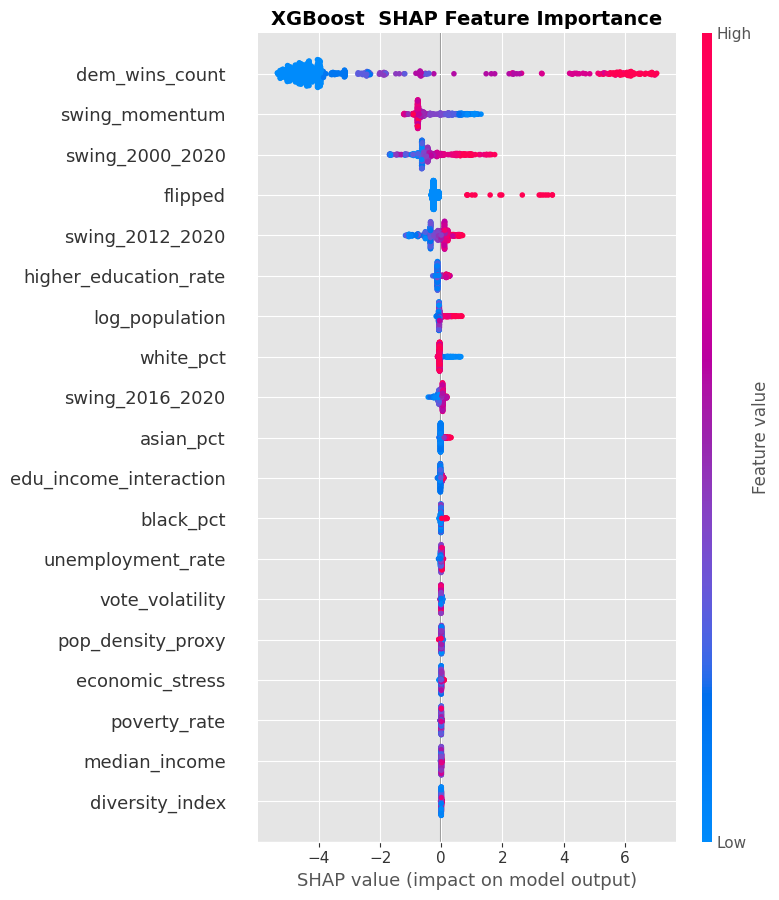

In [ ]:
#  SHAP Explainability for XGBoost
explainer  = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('XGBoost  SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

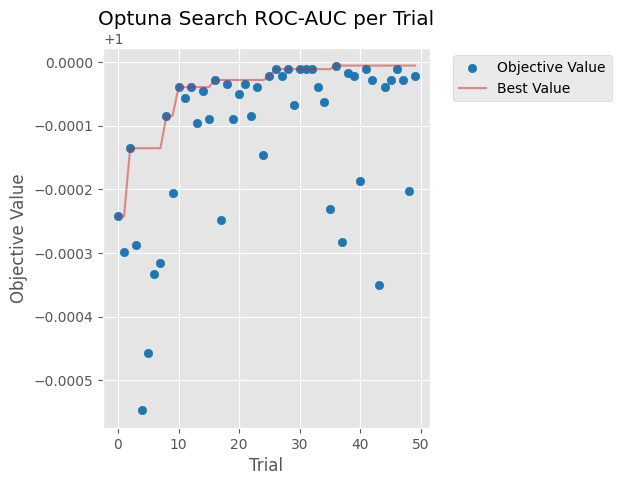

In [ ]:
#  Optuna Optimization History
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna Search ROC-AUC per Trial')
plt.tight_layout()
plt.show()

---
## Approach 2: Neural Network (MLP Classifier)


In [ ]:
#  Define candidate MLP architectures
architectures = {
    'Shallow  [64]':         (64,),
    'Medium   [128, 64]':    (128, 64),
    'Deep     [256,128,64]': (256, 128, 64),
    'Wide     [512, 256]':   (512, 256),
}

mlp_cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('  Cross-validating MLP architectures...')
for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        alpha=0.001,          # L2 regularization
        learning_rate='adaptive',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    scores = cross_val_score(mlp, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    mlp_cv_results[name] = scores
    print(f'  {name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

# Pick best
best_arch_name = max(mlp_cv_results, key=lambda k: mlp_cv_results[k].mean())
best_layers    = architectures[best_arch_name]
print(f' Best architecture: {best_arch_name}')

  Cross-validating MLP architectures...
  Shallow  [64]: ROC-AUC = 0.9974 ± 0.0022
  Medium   [128, 64]: ROC-AUC = 0.9977 ± 0.0023
  Deep     [256,128,64]: ROC-AUC = 0.9995 ± 0.0003
  Wide     [512, 256]: ROC-AUC = 0.9994 ± 0.0006
 Best architecture: Deep     [256,128,64]


In [ ]:
#  Train best MLP on full training set
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
best_mlp.fit(X_train_sc, y_train)

mlp_preds = best_mlp.predict(X_test_sc)
mlp_proba = best_mlp.predict_proba(X_test_sc)[:, 1]

mlp_results = {
    'Accuracy':  accuracy_score(y_test, mlp_preds),
    'Precision': precision_score(y_test, mlp_preds),
    'Recall':    recall_score(y_test, mlp_preds),
    'F1':        f1_score(y_test, mlp_preds),
    'ROC-AUC':   roc_auc_score(y_test, mlp_proba)
}

print(' Neural Network (MLP) Results:')
for k, v in mlp_results.items():
    print(f'  {k}: {v:.4f}')

 Neural Network (MLP) Results:
  Accuracy: 0.9936
  Precision: 0.9640
  Recall: 1.0000
  F1: 0.9817
  ROC-AUC: 1.0000


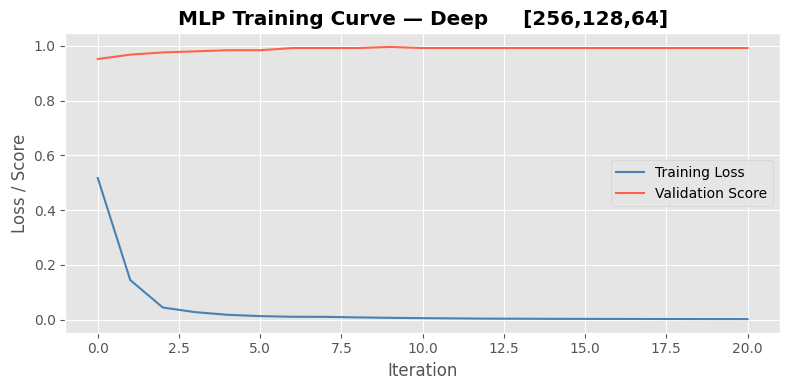

In [ ]:
#  MLP Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(best_mlp.loss_curve_, label='Training Loss', color='steelblue')
if hasattr(best_mlp, 'validation_scores_'):
    plt.plot(best_mlp.validation_scores_, label='Validation Score', color='tomato')
plt.xlabel('Iteration')
plt.ylabel('Loss / Score')
plt.title(f'MLP Training Curve — {best_arch_name}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

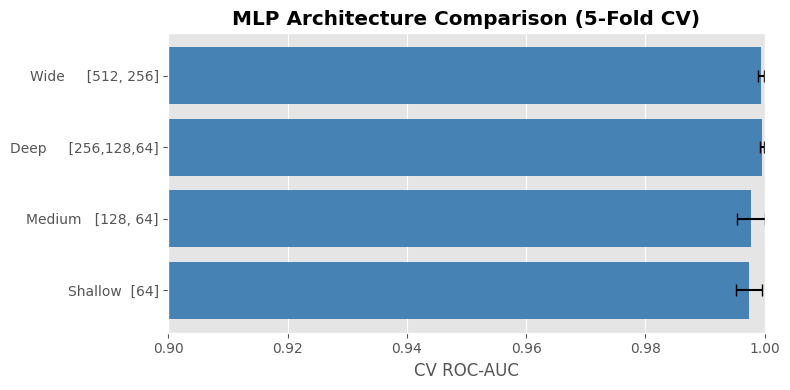

In [ ]:
#  Architecture comparison bar chart
arch_means = {k: v.mean() for k, v in mlp_cv_results.items()}
arch_stds  = {k: v.std()  for k, v in mlp_cv_results.items()}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(arch_means.keys()), list(arch_means.values()),
               xerr=list(arch_stds.values()), color='steelblue', capsize=4)
ax.set_xlabel('CV ROC-AUC')
ax.set_title('MLP Architecture Comparison (5-Fold CV)', fontweight='bold')
ax.set_xlim(0.9, 1.0)
plt.tight_layout()
plt.show()

---
## Approach 3: Stacked Ensemble (Meta-Learning)



In [ ]:
#  Define base models
base_estimators = [
    ('lr',  Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ])),
    ('rf',  RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
    ('xgb', xgb.XGBClassifier(
        **study.best_params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
]

#  Meta-learner
meta_learner = LogisticRegression(C=1.0, max_iter=500, random_state=42)

#  Stacking Classifier
stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,                   # 5-fold CV to generate meta-features
    stack_method='predict_proba',
    passthrough=False,      # Only pass base model probs to meta-learner
    n_jobs=-1
)

stack_clf.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('clf',
                                                 LogisticRegression(max_iter=1000,
                                                                    random_state=42))])),
                               ('rf',
                                RandomForestClassifier(max_depth=15,
                                                       min_samples_leaf=2,
                                                       n_estimators=300,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample...
                                              learning_rate=0.036302004221342,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=7,
                                              max_leaves=None,
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=205, n_jobs=-1,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=500,
                                                      random_state=42),
                   n_jobs=-1, stack_method='predict_proba')

In [ ]:
stack_preds = stack_clf.predict(X_test)
stack_proba = stack_clf.predict_proba(X_test)[:, 1]

stack_results = {
    'Accuracy':  accuracy_score(y_test, stack_preds),
    'Precision': precision_score(y_test, stack_preds),
    'Recall':    recall_score(y_test, stack_preds),
    'F1':        f1_score(y_test, stack_preds),
    'ROC-AUC':   roc_auc_score(y_test, stack_proba)
}

print(' Stacked Ensemble Results:')
for k, v in stack_results.items():
    print(f'  {k}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, stack_preds, target_names=['Republican (0)', 'Democrat (1)']))

 Stacked Ensemble Results:
  Accuracy: 0.9968
  Precision: 0.9817
  Recall: 1.0000
  F1: 0.9907
  ROC-AUC: 1.0000

Classification Report:
                precision    recall  f1-score   support

Republican (0)       1.00      1.00      1.00       516
  Democrat (1)       0.98      1.00      0.99       107

      accuracy                           1.00       623
     macro avg       0.99      1.00      0.99       623
  weighted avg       1.00      1.00      1.00       623



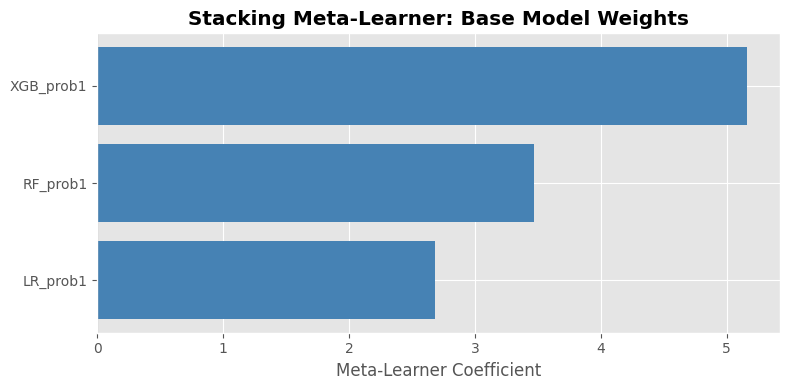

In [ ]:
#  Contribution of each base model
# The meta-learner's coefficients show how much it weighs each base model
meta = stack_clf.final_estimator_
coef = meta.coef_[0]

# Each base model contributes 1 probability column (for class 1) to the meta-learner
model_names  = ['LR_prob1', 'RF_prob1', 'XGB_prob1']
coef_df = pd.DataFrame({'Feature': model_names, 'Meta-Weight': coef})

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Meta-Weight']]
ax.barh(coef_df['Feature'], coef_df['Meta-Weight'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Meta-Learner Coefficient')
ax.set_title('Stacking Meta-Learner: Base Model Weights', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Final Comparison  All Approaches

In [ ]:
#  Compile all results
# Original project baselines
original_results = {
    'LR (Original)':           {'Accuracy': 0.9690, 'F1': 0.8950, 'ROC-AUC': 0.9968},
    'Decision Tree (Original)':{'Accuracy': 0.9788, 'F1': 0.9249, 'ROC-AUC': 0.9986},
    'Random Forest (Original)':{'Accuracy': 0.9723, 'F1': 0.9040, 'ROC-AUC': 0.9972},
}

new_results = {
    'XGBoost + Optuna':  {k: xgb_results[k]   for k in ['Accuracy', 'F1', 'ROC-AUC']},
    'MLP Neural Net':    {k: mlp_results[k]    for k in ['Accuracy', 'F1', 'ROC-AUC']},
    'Stacked Ensemble':  {k: stack_results[k]  for k in ['Accuracy', 'F1', 'ROC-AUC']},
}

all_results = {**original_results, **new_results}
results_df  = pd.DataFrame(all_results).T
results_df.index.name = 'Model'

# Highlight best in each column
styled = results_df.style \
    .format('{:.4f}') \
    .highlight_max(axis=0, color='lightgreen') \
    .set_caption(' Model Comparison: Original vs New Approaches')

display(styled)
print(results_df.to_string())

,Accuracy,F1,ROC-AUC
Model,,,
LR (Original),0.9690,0.8950,0.9968
Decision Tree (Original),0.9788,0.9249,0.9986
Random Forest (Original),0.9723,0.9040,0.9972
XGBoost + Optuna,0.9984,0.9953,1.0000
MLP Neural Net,0.9936,0.9817,1.0000
Stacked Ensemble,0.9968,0.9907,1.0000


                          Accuracy        F1   ROC-AUC
Model                                                 
LR (Original)             0.969000  0.895000  0.996800
Decision Tree (Original)  0.978800  0.924900  0.998600
Random Forest (Original)  0.972300  0.904000  0.997200
XGBoost + Optuna          0.998395  0.995349  1.000000
MLP Neural Net            0.993579  0.981651  0.999964
Stacked Ensemble          0.996790  0.990741  0.999964


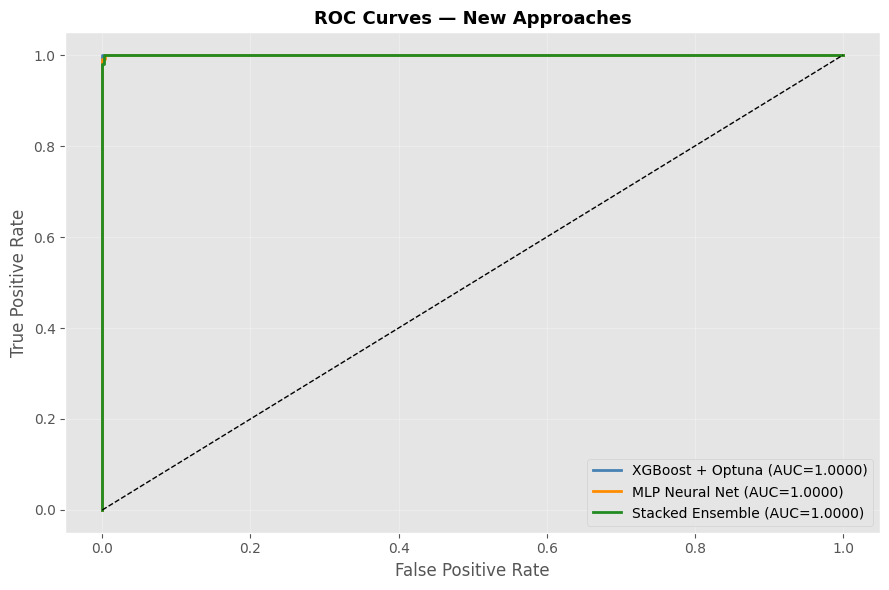

In [ ]:
#  ROC Curve Comparison
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 6))

for label, proba, color in [
    ('XGBoost + Optuna', xgb_proba,   'steelblue'),
    ('MLP Neural Net',   mlp_proba,   'darkorange'),
    ('Stacked Ensemble', stack_proba, 'forestgreen'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc_val:.4f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — New Approaches', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

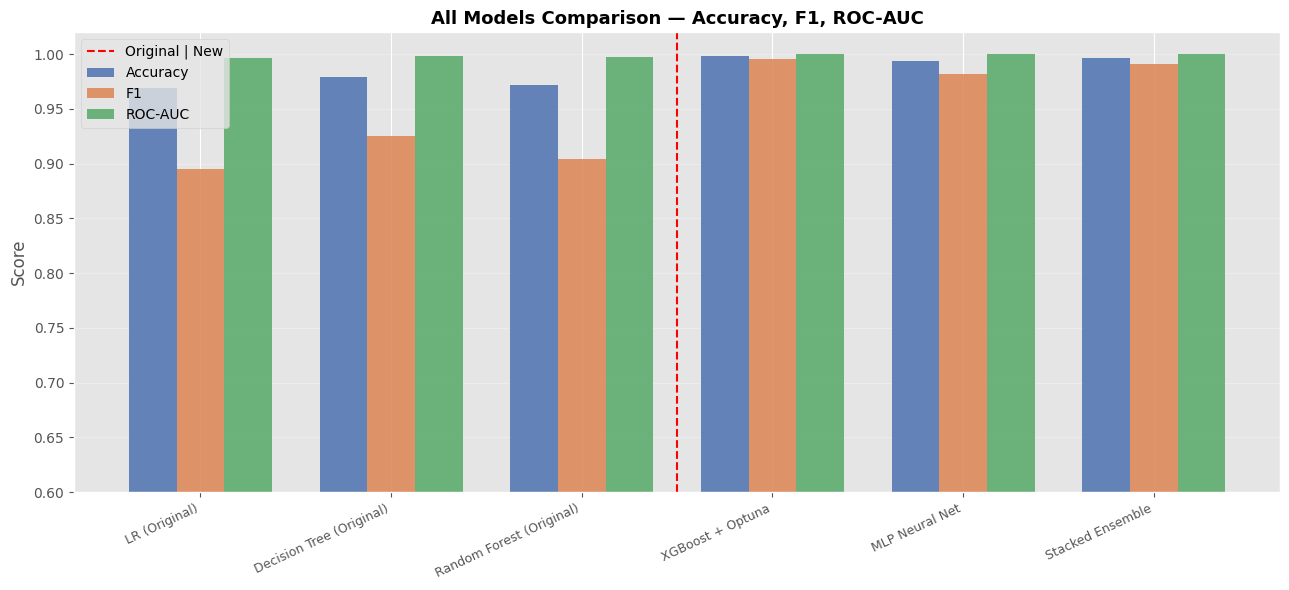

In [ ]:
#  Grouped bar chart: All models
metrics   = ['Accuracy', 'F1', 'ROC-AUC']
models    = list(all_results.keys())
x         = np.arange(len(models))
width     = 0.25
colors    = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [all_results[m][metric] for m in models]
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)

# Divider between original and new
ax.axvline(x=len(original_results) - 0.5 + width, color='red',
           linestyle='--', lw=1.5, label='Original | New')

ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel('Score')
ax.set_title('All Models Comparison — Accuracy, F1, ROC-AUC', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

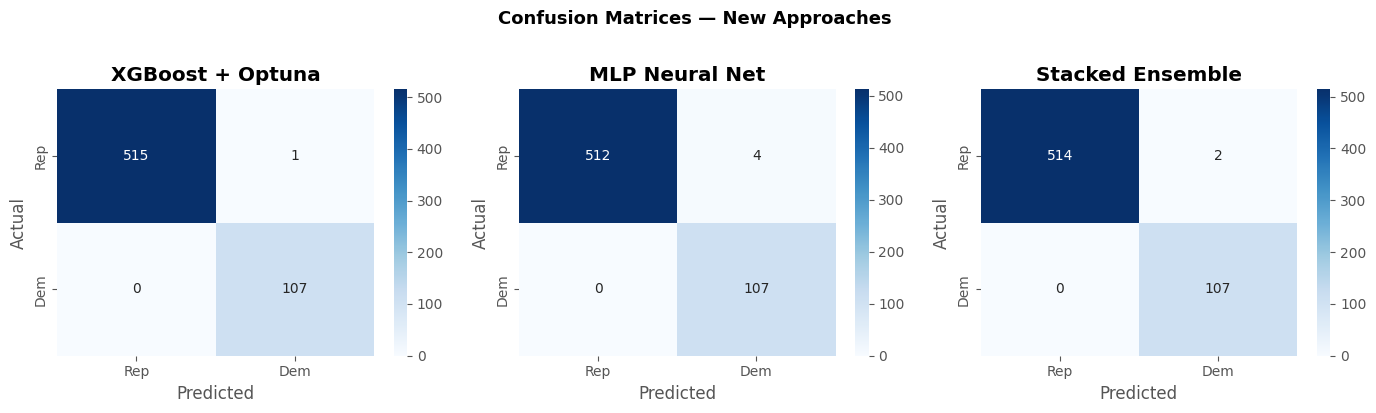

In [ ]:
#  Confusion matrices for new models
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models_data = [
    ('XGBoost + Optuna', xgb_preds),
    ('MLP Neural Net',   mlp_preds),
    ('Stacked Ensemble', stack_preds),
]
for ax, (name, preds) in zip(axes, models_data):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rep', 'Dem'], yticklabels=['Rep', 'Dem'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — New Approaches', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()